# Import Packages

In [1]:
# importing packages
import numpy as np # to perform calculations 
import pandas as pd # to read data
import matplotlib.pyplot as plt # to visualise

In [2]:
df = pd.read_csv("creditcard.csv")

In [3]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [12]:
# Check Balance of results of Data Set

df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [14]:
# Split the data into features and target variables
X = df.drop('Class', axis=1) # Feature Variables
y = df['Class'] # Target Variables

In [15]:
# Train test split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [16]:
# Make train test split
X_train, X_test, y_train, y_test = train_test_split(X,  y,  test_size=0.2, stratify=y, random_state=42)

In [17]:
# Scale the data

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
# Create Deep Learning model
import torch

In [19]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

In [20]:
# Create a neural network
import torch.nn as nn

In [21]:
class FraudModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.network(x)

In [58]:
model = FraudModel(X_train_tensor.shape[1])

criterion = nn.BCEWithLogitsLoss() # Binary Cross Entropy
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [59]:
# Train Model

epochs = 100

for epoch in range(epochs):
    model.train()

    logits = model(X_train_tensor)
    loss = criterion(logits, y_train_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

Epoch 1/100, Loss: 0.6958
Epoch 2/100, Loss: 0.6806
Epoch 3/100, Loss: 0.6654
Epoch 4/100, Loss: 0.6503
Epoch 5/100, Loss: 0.6351
Epoch 6/100, Loss: 0.6200
Epoch 7/100, Loss: 0.6049
Epoch 8/100, Loss: 0.5898
Epoch 9/100, Loss: 0.5748
Epoch 10/100, Loss: 0.5597
Epoch 11/100, Loss: 0.5447
Epoch 12/100, Loss: 0.5297
Epoch 13/100, Loss: 0.5146
Epoch 14/100, Loss: 0.4996
Epoch 15/100, Loss: 0.4846
Epoch 16/100, Loss: 0.4696
Epoch 17/100, Loss: 0.4546
Epoch 18/100, Loss: 0.4397
Epoch 19/100, Loss: 0.4248
Epoch 20/100, Loss: 0.4099
Epoch 21/100, Loss: 0.3951
Epoch 22/100, Loss: 0.3803
Epoch 23/100, Loss: 0.3657
Epoch 24/100, Loss: 0.3511
Epoch 25/100, Loss: 0.3367
Epoch 26/100, Loss: 0.3225
Epoch 27/100, Loss: 0.3084
Epoch 28/100, Loss: 0.2946
Epoch 29/100, Loss: 0.2810
Epoch 30/100, Loss: 0.2676
Epoch 31/100, Loss: 0.2546
Epoch 32/100, Loss: 0.2419
Epoch 33/100, Loss: 0.2295
Epoch 34/100, Loss: 0.2175
Epoch 35/100, Loss: 0.2058
Epoch 36/100, Loss: 0.1946
Epoch 37/100, Loss: 0.1838
Epoch 38/1

In [60]:
#Evaluate the results

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

model.eval()

with torch.no_grad():
    test_logits = model(X_test_tensor)
    probabilities = torch.sigmoid(test_logits)
    predictions = (probabilities >= 0.5).int()

print(confusion_matrix(y_test_tensor.numpy(), predictions.numpy()))
print(classification_report(y_test_tensor.numpy(), predictions.numpy()))
print("ROC AUC:", roc_auc_score(y_test_tensor.numpy(), probabilities.numpy()))

[[56864     0]
 [   98     0]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     56864
         1.0       0.00      0.00      0.00        98

    accuracy                           1.00     56962
   macro avg       0.50      0.50      0.50     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC: 0.86213956249354


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

### Analysis of initial run

As we can see, the model marked everything as not being fradulent. Before further investigation, my instincts hypothesize that the reason for this is because of how imbalanced the dataset is, the model figured the easiest way to minimize the loss is by simply marking everything as being non fradulent, since 56864/56962 (~99.8%) of the test data are non-fraudulent charges.

There are a few ways to approach this, I think the easiest applicable way is to add a larger penalty to the loss whenever the model is wrong about the model not being fraudulent (models real life circumstances and severity)


In [61]:
# Calculate the imbalance ratio
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
pos_weight = torch.tensor([neg / pos], dtype=torch.float32)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)


"""
pos_weight tells the loss: "a false negative on a fraud case should cost this many times more than a false positive." 
Since the dataset has roughly 99% normal and 1% fraud, pos_weight would be ~99, making the model pay heavily for missing fraud.
"""

'\npos_weight tells the loss: "a false negative on a fraud case should cost this many times more than a false positive." \nSince the dataset has roughly 99% normal and 1% fraud, pos_weight would be ~99, making the model pay heavily for missing fraud.\n'

In [62]:
# Train Model

epochs = 100

for epoch in range(epochs):
    model.train()

    logits = model(X_train_tensor)
    loss = criterion(logits, y_train_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

Epoch 1/100, Loss: 2.4635
Epoch 2/100, Loss: 2.3527
Epoch 3/100, Loss: 2.2089
Epoch 4/100, Loss: 2.0553
Epoch 5/100, Loss: 1.9043
Epoch 6/100, Loss: 1.7619
Epoch 7/100, Loss: 1.6308
Epoch 8/100, Loss: 1.5120
Epoch 9/100, Loss: 1.4042
Epoch 10/100, Loss: 1.3068
Epoch 11/100, Loss: 1.2187
Epoch 12/100, Loss: 1.1393
Epoch 13/100, Loss: 1.0682
Epoch 14/100, Loss: 1.0045
Epoch 15/100, Loss: 0.9475
Epoch 16/100, Loss: 0.8966
Epoch 17/100, Loss: 0.8510
Epoch 18/100, Loss: 0.8105
Epoch 19/100, Loss: 0.7746
Epoch 20/100, Loss: 0.7428
Epoch 21/100, Loss: 0.7147
Epoch 22/100, Loss: 0.6899
Epoch 23/100, Loss: 0.6680
Epoch 24/100, Loss: 0.6484
Epoch 25/100, Loss: 0.6309
Epoch 26/100, Loss: 0.6152
Epoch 27/100, Loss: 0.6010
Epoch 28/100, Loss: 0.5881
Epoch 29/100, Loss: 0.5763
Epoch 30/100, Loss: 0.5654
Epoch 31/100, Loss: 0.5552
Epoch 32/100, Loss: 0.5456
Epoch 33/100, Loss: 0.5364
Epoch 34/100, Loss: 0.5277
Epoch 35/100, Loss: 0.5193
Epoch 36/100, Loss: 0.5111
Epoch 37/100, Loss: 0.5032
Epoch 38/1

In [63]:
#Evaluate the results again

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

model.eval()

with torch.no_grad():
    test_logits = model(X_test_tensor)
    probabilities = torch.sigmoid(test_logits)
    predictions = (probabilities >= 0.5).int()

print(confusion_matrix(y_test_tensor.numpy(), predictions.numpy()))
print(classification_report(y_test_tensor.numpy(), predictions.numpy()))
print("ROC AUC:", roc_auc_score(y_test_tensor.numpy(), probabilities.numpy()))

[[56061   803]
 [   11    87]]
              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99     56864
         1.0       0.10      0.89      0.18        98

    accuracy                           0.99     56962
   macro avg       0.55      0.94      0.58     56962
weighted avg       1.00      0.99      0.99     56962

ROC AUC: 0.9784103568270301


# Evaluation Pt 2.

As we can see, after including the penalty we decreased the number of false positives significantly from 98 to 11 cases (or a ~89% decrease). However, with that we see that the number of false negatives (cases that were counted as fraud but were not) surged a lot from 0 to 803.

In order to adjust this further investigation of the results is required

First I will create a probability distribution plot to see if it may be beneficial to adjust the threshold of the model

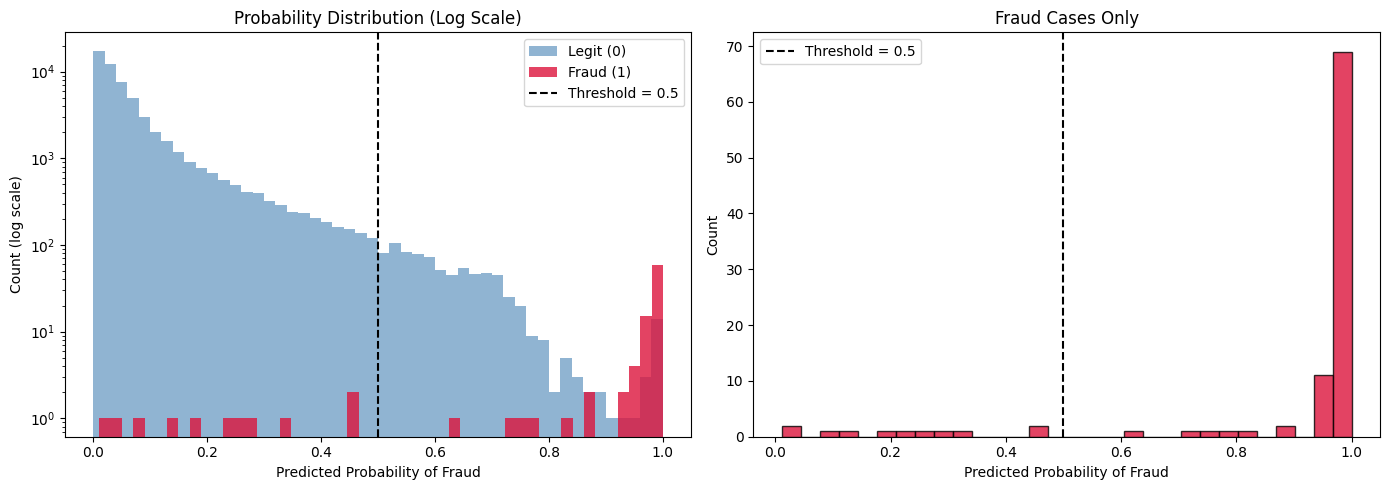

In [64]:
# Separate probabilities by true class
fraud_probs = probabilities.numpy()[y_test_tensor.numpy() == 1]
legit_probs = probabilities.numpy()[y_test_tensor.numpy() == 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Probability Distribution
axes[0].hist(legit_probs, bins=50, alpha=0.6, color='steelblue', label='Legit (0)')
axes[0].hist(fraud_probs, bins=50, alpha=0.8, color='crimson', label='Fraud (1)')
axes[0].axvline(x=0.5, color='black', linestyle='--', label='Threshold = 0.5')
axes[0].set_yscale('log')  # log scale so fraud bars are visible
axes[0].set_xlabel('Predicted Probability of Fraud')
axes[0].set_ylabel('Count (log scale)')
axes[0].set_title('Probability Distribution (Log Scale)')
axes[0].legend()


# Plot 2: Recall vs Precision across thresholds 
from sklearn.metrics import precision_recall_curve

axes[1].hist(fraud_probs, bins=30, color='crimson', alpha=0.8, edgecolor='black')
axes[1].axvline(x=0.5, color='black', linestyle='--', label='Threshold = 0.5')
axes[1].set_xlabel('Predicted Probability of Fraud')
axes[1].set_ylabel('Count')
axes[1].set_title('Fraud Cases Only')
axes[1].legend()

plt.tight_layout()
plt.show()

As we can see, a high majority of the fraud cases are above the 0.9 threshold, lets see the results of the model when we implement that threshold change

In [65]:
#Evaluate the results again

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

model.eval()

with torch.no_grad():
    test_logits = model(X_test_tensor)
    probabilities = torch.sigmoid(test_logits)
    predictions = (probabilities >= 0.9).int()

print(confusion_matrix(y_test_tensor.numpy(), predictions.numpy()))
print(classification_report(y_test_tensor.numpy(), predictions.numpy()))
print("ROC AUC:", roc_auc_score(y_test_tensor.numpy(), probabilities.numpy()))

[[56844    20]
 [   18    80]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     56864
         1.0       0.80      0.82      0.81        98

    accuracy                           1.00     56962
   macro avg       0.90      0.91      0.90     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC: 0.9784103568270301


As we can see, the number of false negative cases did increase by a lot, but the number of false positive cases also increased

What we can now do to decrease the number of false positives is to oversample the fraud cases during training. This will allow the model to have more practice seeing fraud cases so that it can better recognize them

to do this we will be using SMOTE

In [77]:
from imblearn.over_sampling import SMOTE

# Create the resampled data
sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_train, y_train) 

# Then convert to tensors 
X_train_tensor = torch.tensor(X_resampled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_resampled.values, dtype=torch.float32)

In [78]:
# Rerun the model

model = FraudModel(X_train_tensor.shape[1])

# Calculate the imbalance ratio
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
pos_weight = torch.tensor([neg / pos], dtype=torch.float32)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)


"""
pos_weight tells the loss: "a false negative on a fraud case should cost this many times more than a false positive." 
Since the dataset has roughly 99% normal and 1% fraud, pos_weight would be ~99, making the model pay heavily for missing fraud.
"""

'\npos_weight tells the loss: "a false negative on a fraud case should cost this many times more than a false positive." \nSince the dataset has roughly 99% normal and 1% fraud, pos_weight would be ~99, making the model pay heavily for missing fraud.\n'

In [79]:
# Train Model
class FraudModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.network(x)

In [101]:
model = FraudModel(X_train_tensor.shape[1])  # reinitialize weights
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [102]:
epochs = 150

for epoch in range(epochs):
    model.train()

    logits = model(X_train_tensor).squeeze()
    loss = criterion(logits, y_train_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

Epoch 1/150, Loss: 234.9389
Epoch 2/150, Loss: 215.5872
Epoch 3/150, Loss: 198.1388
Epoch 4/150, Loss: 182.6261
Epoch 5/150, Loss: 168.9556
Epoch 6/150, Loss: 156.9460
Epoch 7/150, Loss: 146.3002
Epoch 8/150, Loss: 136.6872
Epoch 9/150, Loss: 127.8794
Epoch 10/150, Loss: 119.7638
Epoch 11/150, Loss: 112.2524
Epoch 12/150, Loss: 105.2744
Epoch 13/150, Loss: 98.7887
Epoch 14/150, Loss: 92.7506
Epoch 15/150, Loss: 87.1296
Epoch 16/150, Loss: 81.9036
Epoch 17/150, Loss: 77.0434
Epoch 18/150, Loss: 72.5144
Epoch 19/150, Loss: 68.2977
Epoch 20/150, Loss: 64.3747
Epoch 21/150, Loss: 60.7284
Epoch 22/150, Loss: 57.3352
Epoch 23/150, Loss: 54.1730
Epoch 24/150, Loss: 51.2260
Epoch 25/150, Loss: 48.4789
Epoch 26/150, Loss: 45.9185
Epoch 27/150, Loss: 43.5270
Epoch 28/150, Loss: 41.2856
Epoch 29/150, Loss: 39.1796
Epoch 30/150, Loss: 37.1970
Epoch 31/150, Loss: 35.3271
Epoch 32/150, Loss: 33.5626
Epoch 33/150, Loss: 31.8966
Epoch 34/150, Loss: 30.3243
Epoch 35/150, Loss: 28.8415
Epoch 36/150, Los

In [106]:
model.eval()

with torch.no_grad():
    test_logits = model(X_test_tensor)
    probabilities = torch.sigmoid(test_logits)
    predictions = (probabilities >= 0.9).int()

print(confusion_matrix(y_test_tensor.numpy(), predictions.numpy()))
print(classification_report(y_test_tensor.numpy(), predictions.numpy()))
print("ROC AUC:", roc_auc_score(y_test_tensor.numpy(), probabilities.numpy()))

[[28404 28460]
 [    2    96]]
              precision    recall  f1-score   support

         0.0       1.00      0.50      0.67     56864
         1.0       0.00      0.98      0.01        98

    accuracy                           0.50     56962
   macro avg       0.50      0.74      0.34     56962
weighted avg       1.00      0.50      0.67     56962

ROC AUC: 0.9677713850734442


The result ended in an overcorrection where the model got so good at recognizing fraud that it forgot what real looked like. In order to fix this I will soften the SMOTE. so that it is not 50/50

To aid this i will iteratively test different SMOTE ratios to see which one is optimal for training the model

In [112]:

from sklearn.metrics import precision_score


# Fix test tensor shape once before the loop
y_test_tensor_fixed = y_test_tensor.squeeze()   # (56962,1) to (56962,)
X_test_tensor_fixed = X_test_tensor.clone()

sampling_strategies = [0.05, 0.1, 0.2, 0.25, 0.3, 0.35, 0.5]
results = []

for strategy in sampling_strategies:

    # Resample
    sm = SMOTE(random_state=42, sampling_strategy=strategy)
    X_res, y_res = sm.fit_resample(X_train, y_train)
    X_res_tensor = torch.tensor(X_res, dtype=torch.float32)
    y_res_tensor = torch.tensor(y_res.values, dtype=torch.float32)  # flat (n,)

    # Recalculate pos_weight from original y_train (not resampled)
    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    pos_weight = torch.tensor([neg / pos], dtype=torch.float32)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    # Retrain from scratch
    model = FraudModel(X_res_tensor.shape[1])
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(100):
        model.train()
        logits = model(X_res_tensor).squeeze()   # (n,1) → (n,)
        loss = criterion(logits, y_res_tensor)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Evaluate on held-out test set
    model.eval()
    with torch.no_grad():
        test_logits = model(X_test_tensor_fixed)
        probs = torch.sigmoid(test_logits).squeeze()
        preds = (probs >= 0.9).int()

    y_true = y_test_tensor_fixed.numpy()
    y_pred = preds.numpy()

    r = {
        'sampling_strategy': strategy,
        'precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'recall':    round(recall_score(y_true, y_pred), 4),
        'f1':        round(f1_score(y_true, y_pred, zero_division=0), 4),
        'false_negatives': int(((y_true == 1) & (y_pred == 0)).sum()),
        'false_positives': int(((y_true == 0) & (y_pred == 1)).sum())
    }
    results.append(r)
    print(f"strategy={strategy:.2f} | P={r['precision']} R={r['recall']} F1={r['f1']} | FN={r['false_negatives']} FP={r['false_positives']}")

print("\n", pd.DataFrame(results).to_string(index=False))

strategy=0.05 | P=0.0283 R=0.9082 F1=0.0549 | FN=9 FP=3058
strategy=0.10 | P=0.0156 R=0.9286 F1=0.0307 | FN=7 FP=5744
strategy=0.20 | P=0.005 R=0.9796 F1=0.0099 | FN=2 FP=19289
strategy=0.25 | P=0.0078 R=0.949 F1=0.0154 | FN=5 FP=11873
strategy=0.30 | P=0.0164 R=0.9286 F1=0.0323 | FN=7 FP=5444
strategy=0.35 | P=0.0043 R=0.9898 F1=0.0086 | FN=1 FP=22312
strategy=0.50 | P=0.0037 R=0.9796 F1=0.0075 | FN=2 FP=25535

  sampling_strategy  precision  recall     f1  false_negatives  false_positives
              0.05     0.0283  0.9082 0.0549                9             3058
              0.10     0.0156  0.9286 0.0307                7             5744
              0.20     0.0050  0.9796 0.0099                2            19289
              0.25     0.0078  0.9490 0.0154                5            11873
              0.30     0.0164  0.9286 0.0323                7             5444
              0.35     0.0043  0.9898 0.0086                1            22312
              0.50     0.0037 

torch.Size([56962, 1])
torch.Size([56962, 30])
